In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import random
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import math
from timeit import timeit
import os


Given an arithmetic sequence $(U_n)$ of step $r$ and a first term $U_{min}$,  any element $U_n$ in the sequence can be computed as $U_n = U_{min} + n ⋅ r$. Therefore the indice of the element $U_n$ in the sequence is $n = \frac{U_n - U_{min}}{r}$. A function that implements this idea:

In [ ]:

def normalize_angle(a):
    return ((a + 180) % 360) - 180

def get_idx(v, min_v=0.0, step=0.5):
    return round((v-min_v)/step)

In [ ]:
normalize_angle(180)

-180

**Kinematic Model of the Robot**
Here we will simply implement the simple kinematic model introduced in the blog post. Another robot model can be implemented since it will be modular

Given the previous pose or configuration $(x_{t-1}, y_{t-1}, θ_{t-1})$ of the robot, the next configuration can be computed as follow:
$x_t = x_{t-1} + v_t⋅cos(θ_{t-1}) $

$y_t = y_{t-1} + v_t⋅sin(θ_{t-1}) $

$x_t = x_{t-1} + Δθ_t $

with $v_t, Δθ_t$ being the velocity and orientation inputs at time step t. In our case, the robot can either rotate or move at a given time step, but not both at the same time. However, as I said, it is possible to change this kinematic and plug it to the value iteration allgorithm that we are going to implement

In [ ]:
class Robot:
    def __init__(self, velocity=1.0, delta_theta=90.0) -> None:

        self.velocity = velocity
        self.delta_theta = delta_theta
        self.action_space = actions = ["stop", "move", "turn left", "turn right"]

        self.reset()

    def update(self, action):

        """ Update the kinematic of the robot given an action """
        if action=="move":
            #print(f"before: {self.x}-->{get_idx(self.x, -10.0, 0.5)}, {self.y}-->{get_idx(self.y, -10.0, 0.5)}, theta:{self.theta}")
            self.x = self.x + self.velocity*math.cos(math.radians(self.theta))
            self.y = self.y + self.velocity*math.sin(math.radians(self.theta))
            #print(f"after: {self.x}-->{get_idx(self.x, -10.0, 0.5)}, {self.y}-->{get_idx(self.y, -10.0, 0.5)},  theta:{self.theta}")

        elif action=="stop":
            pass

        elif action=="turn left":
            self.theta = normalize_angle(self.theta - self.delta_theta) #max(-180, self.theta - self.delta_theta)

        elif action=="turn right":
            self.theta = normalize_angle(self.theta + self.delta_theta) #min(self.theta + self.delta_theta, 180)

        else:
            raise f"action <{action}> does not exist in action space: {self.action_space}"


    def get_random_action(self):

        return random.choice(self.action_space)

    def reset(self, pose:np.ndarray|None=None):
        """ Reset the robot pose x, y, theta"""
        if pose is not None:
            self.x = pose[0].item()
            self.y = pose[1].item()
            self.theta = pose[2].item()
        else:
            self.x = 0.0
            self.y = 0.0
            self.theta = 0.0

    def print_pose(self):

        """ Simple print of the robot current pose"""
        print(f"X: {self.x} \tY: {self.y} \tTheta: {self.theta}")

In [ ]:
class GridEnv:
    def __init__(self, X_limit, Y_limit, position_step, heading_step, rb:Robot, goal_position:np.ndarray | list) -> None:

        self.X_limit = X_limit
        self.Y_limit = Y_limit

        self.x_space = np.arange(X_limit[0], X_limit[1]+0.5, position_step)
        self.y_space = np.arange(Y_limit[0], Y_limit[1]+0.5, position_step)
        self.heading_space = np.arange(-180.0, 180.0, heading_step)


        # Create full grid
        X, Y, H = np.meshgrid(
            self.x_space,
            self.y_space,
            self.heading_space,
            indexing='ij'
        )

        # Flatten into giant list of tuples
        self.state_space = np.vstack([X.ravel(), Y.ravel(), H.ravel()]).T
        self.position_step = position_step
        self.heading_step = heading_step

        #discretizing the goal position
        goal_pos_x = self.x_space[get_idx(goal_position[0], X_limit[0], position_step)]
        goal_pos_y = self.y_space[get_idx(goal_position[1], Y_limit[0], position_step)]

        self.goal_position = np.array([goal_pos_x, goal_pos_y]) # discretized goal position which is the real pos in the grid world;

        self.rb = rb # Robot

        self.action_space = rb.action_space

        self.state = self.reset()

    def reset(self, pose:np.ndarray | None = None):

        self.rb.reset(pose)

        init_state = self.get_current_state()

        return init_state


    def reward_model(self, state, action , next_state):
        """ Return the reward of a transition. returns 0 if distance = 0, -1 otherwise """

        goal_reached = np.array_equal(next_state[:2], self.goal_position)
        distance = (np.linalg.norm(state[:2] - self.goal_position))/15
        #print(distance, state, next_state)

        return -float(not goal_reached) #- distance


    def step(self, action):

        # update the robot pose
        #print(f"before step:")
        #self.rb.print_pose()

        state = self.get_current_state()

        self.rb.update(action)
        #print(f"action: {action}")

        #print(f"x: {self.rb.x}, y: {self.rb.y}")

        self.rb.x = min(max(self.rb.x, self.X_limit[0]), self.X_limit[1])
        self.rb.y = min(max(self.rb.y, self.Y_limit[0]), self.Y_limit[1])

        next_state = self.get_current_state() # get the state after update
        #print(f"next state: {next_state}")
        reward = self.reward_model(self.state, action, next_state)
        done = (np.array_equal(next_state[:2], self.goal_position))

        self.state = next_state.copy()

        return next_state, reward, done

    def is_terminal_state(self, state):

        return round(state[0])==round(self.goal_position[0]) and round(state[1])==round(self.goal_position[1])

    def get_current_state(self):

        idx_x = get_idx(self.rb.x, self.X_limit[0], self.position_step)
        idx_y = get_idx(self.rb.y, self.Y_limit[0], self.position_step)
        #print(f"x ind: {idx_x}, y_idx: {idx_y}")
        idx_heading = get_idx(self.rb.theta, -180.0, self.heading_step)

        #print(f"idx heading: {idx_heading}")
        pos_x = self.x_space[min(idx_x, len(self.x_space)-1)]
        pos_y = self.y_space[min(idx_y, len(self.y_space)-1)]
        heading = self.heading_space[min(idx_heading, len(self.heading_space)-1)]

        state = np.array([pos_x, pos_y, heading])

        return state

    def state_to_idx(self, state):

        x_idx = get_idx(state[0], self.X_limit[0], self.position_step)
        y_idx = get_idx(state[1], self.Y_limit[0], self.position_step)
        heading_idx = get_idx(state[2], -180.0, self.heading_step)

        N_D = len(self.x_space)
        N_B = len(self.y_space)
        N_H = len(self.heading_space)

        flat_idx = x_idx * (N_B * N_H) + y_idx * N_H + heading_idx

        return flat_idx

    def idx_to_state(self, flat_idx):

        N_D = len(self.x_space)
        N_B = len(self.y_space)
        N_H = len(self.heading_space)

        # Recover the 3 indices
        x_idx = flat_idx // (N_B * N_H)
        rem = flat_idx % (N_B * N_H)

        y_idx = rem // N_H
        heading_idx = rem % N_H

        # Convert indices back to actual state values
        x = self.x_space[x_idx]
        y = self.y_space[y_idx]
        heading = self.heading_space[heading_idx]

        return (x, y, heading)

This code below is called "Value Iteration" but it's actually doing a policy evaluation here, there is no policy improvement as I am merely taking the expectation of the action value Q(s,a) over the action distribution. It was a quick hack to obtain a policy evaluation algorithm directly from the code I had written from the previous chapter

In [ ]:
from tqdm import tqdm

In [ ]:
class ValueIteration:
    def __init__(self, env:GridEnv) -> None:
        self.env = env
        self.value_array = np.random.randn(env.state_space.shape[0]) #np.zeros(env.state_space.shape[0])

        # Zero out terminal states
        for idx, st in enumerate(env.state_space):
            if env.is_terminal_state(st):
                self.value_array[idx] = 0.0

        self.prev_value_array = self.value_array.copy()
        self.gamma = 0.99

        self.trans_matrix = self.create_transition_matrix()
        self.value_delta = []

        self.policy_distribution = {"stop":0.25, "move":0.25, "turn left":0.25, "turn right":0.25}

    def create_transition_matrix(self):
        """
        This is the dynamic funtion of the discrete environment. Instead of calling env.step every step, we simply look-up the next state given current action. However, this is not necessary in MC sampling
        """

        transition = {} # {state: {action1: next_state_1, action2: next_state2, ...}, ...}
        for state in self.env.state_space:
            transition[self.state_to_str(state)] = {}
            for action in self.env.action_space:
                self.env.rb.reset(state)
                next_state, reward, done = self.env.step(action)
                reward = self.env.reward_model(state, action, next_state)
                transition[self.state_to_str(state)][action] = (next_state, reward, done)

        return transition


    def transition_prob(self, state, action, reward, next_state):

        return 1.0

    def get_next_state(self, state, action):

        self.env.rb.reset(state)


        # Get the actual outcome of taking 'action' from 'state_array'
        observed_next_state, observed_reward_from_step, done = self.env.step(action)

        return observed_next_state

    def get_state_next_states(self, state):

        state_dict = {self.state_to_str(state):[]}

        for action in self.env.action_space:
            next_state = self.get_next_state(state, action)
            state_dict[self.state_to_str(state)].append(next_state)

        return state_dict


    def state_to_str(self, state):

        return f"({state[0]}, {state[1]}, {state[2]})"

    def get_value_norm(self, v:np.ndarray):

        return np.linalg.norm(v)

    def run(self, num_iterations:int=20, action_value_file_name="val_iter_value_array", save_frequency=50):

        delta_v = 1
        epsilon = 1e-6
        iter = 0
        self.value_delta = []
        while delta_v>epsilon:

            for state_idx in range(self.env.state_space.shape[0]):
                state_array = self.env.state_space[state_idx]

                if self.env.is_terminal_state(state_array):
                    # do not update terminal state, v(s)=0 if terminal
                    continue

                value_for_state = 0 # Initialize value for the current state to a very low number (for maximization)

                for action in self.env.action_space:

                    next_state_array, reward, done = self.trans_matrix[self.state_to_str(state_array)][action] #[0]
                    # Calculate the reward for transitioning to this candidate_next_state_array
                    #reward = self.env.reward_model(state_array, action, next_state_array)

                    next_state_value = self.value_array[self.env.state_to_idx(next_state_array)]

                    # Pass both the observed next state and observed reward for comparison.
                    prob = self.transition_prob(state_array, action, reward, next_state_array)

                    q_value_for_action = prob * (reward + self.gamma * next_state_value)

                    value_for_state += self.policy_distribution[action]*q_value_for_action

                self.value_array[state_idx] = round(value_for_state, 3)

            norm_v = self.get_value_norm(self.value_array)
            norm_prev_v = self.get_value_norm(self.prev_value_array)
            delta_v = abs(norm_v-norm_prev_v)
            self.value_delta.append(delta_v)
            self.prev_value_array = self.value_array.copy()
            iter += 1

            if iter % save_frequency == 0:
                self.save(self.value_array, file_name=action_value_file_name)

            print(f"=============================================")
            print(f"[ITERATION N°{iter}] delta_v: {delta_v}")

            if iter>=num_iterations:
                break

        self.save(self.value_array, file_name=action_value_file_name)
        return self.value_array

    def save(self, value_array:np.ndarray, save_dir:str="/content/drive/MyDrive/rl_checkpoints/", file_name:str="val_iter_value_array"):
        """ Save the value array on google drive """
        os.makedirs(save_dir, exist_ok=True)

        path = os.path.join(save_dir, file_name+".npy")
        # Save the action-value array
        np.save(path, value_array)

        print(f"Arrays successfully saved to Google Drive!: {path}")

    def load(self, value_array:np.ndarray, save_dir:str="/content/drive/MyDrive/rl_checkpoints/", file_name:str="val_iter_value_array"):

        path = os.path.join(save_dir, file_name+".npy")
        if os.path.exists(path):
            value_array[:] = np.load(path, allow_pickle=True)
            print("Action-value array successfully loaded!")
        else:
            print("Checkpoint file not found.")

In [ ]:
angle_step = 45 # degree
rb1 = Robot(1.1, angle_step)
env1 = GridEnv([-10.0, 10.0], [-10.0, 10.0], 1., angle_step, rb1, np.array([0.0, 0.0]))
valiter = ValueIteration(env1)
test_state = valiter.env.state_space[0]
valiter.get_state_next_states(test_state)


{'(-10.0, -10.0, -180.0)': [array([ -10.,  -10., -180.]),
  array([ -10.,  -10., -180.]),
  array([-10., -10., 135.]),
  array([ -10.,  -10., -135.])]}

In [ ]:
valiter.load(valiter.value_array, file_name="val_iter_value_array")

Action-value array successfully loaded!


In [ ]:
# Correctly use timeit to measure the execution of valiter.run(200)
execution_time = timeit(lambda: valiter.run(200), number=1)
print(f"Execution time for valiter.run(200): {execution_time:.4f} seconds")
print(f"Percentage of updated states: {(np.count_nonzero(valiter.value_array))/(valiter.value_array.shape[0]-1)}")
value_delta_normal = valiter.value_delta.copy()

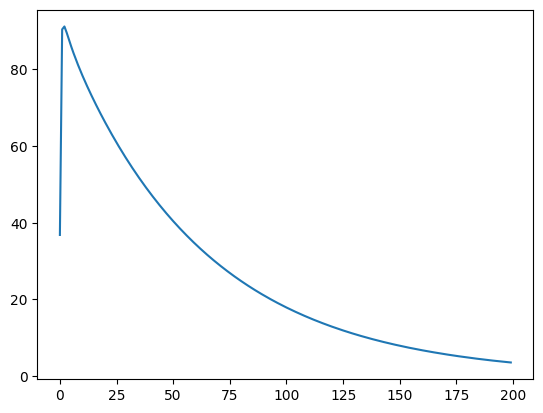

In [ ]:
plt.plot(value_delta_normal)

In [ ]:
value_array = valiter.value_array.copy()

In [ ]:
value_array = value_array.reshape(env1.x_space.shape[0], env1.y_space.shape[0], env1.heading_space.shape[0])

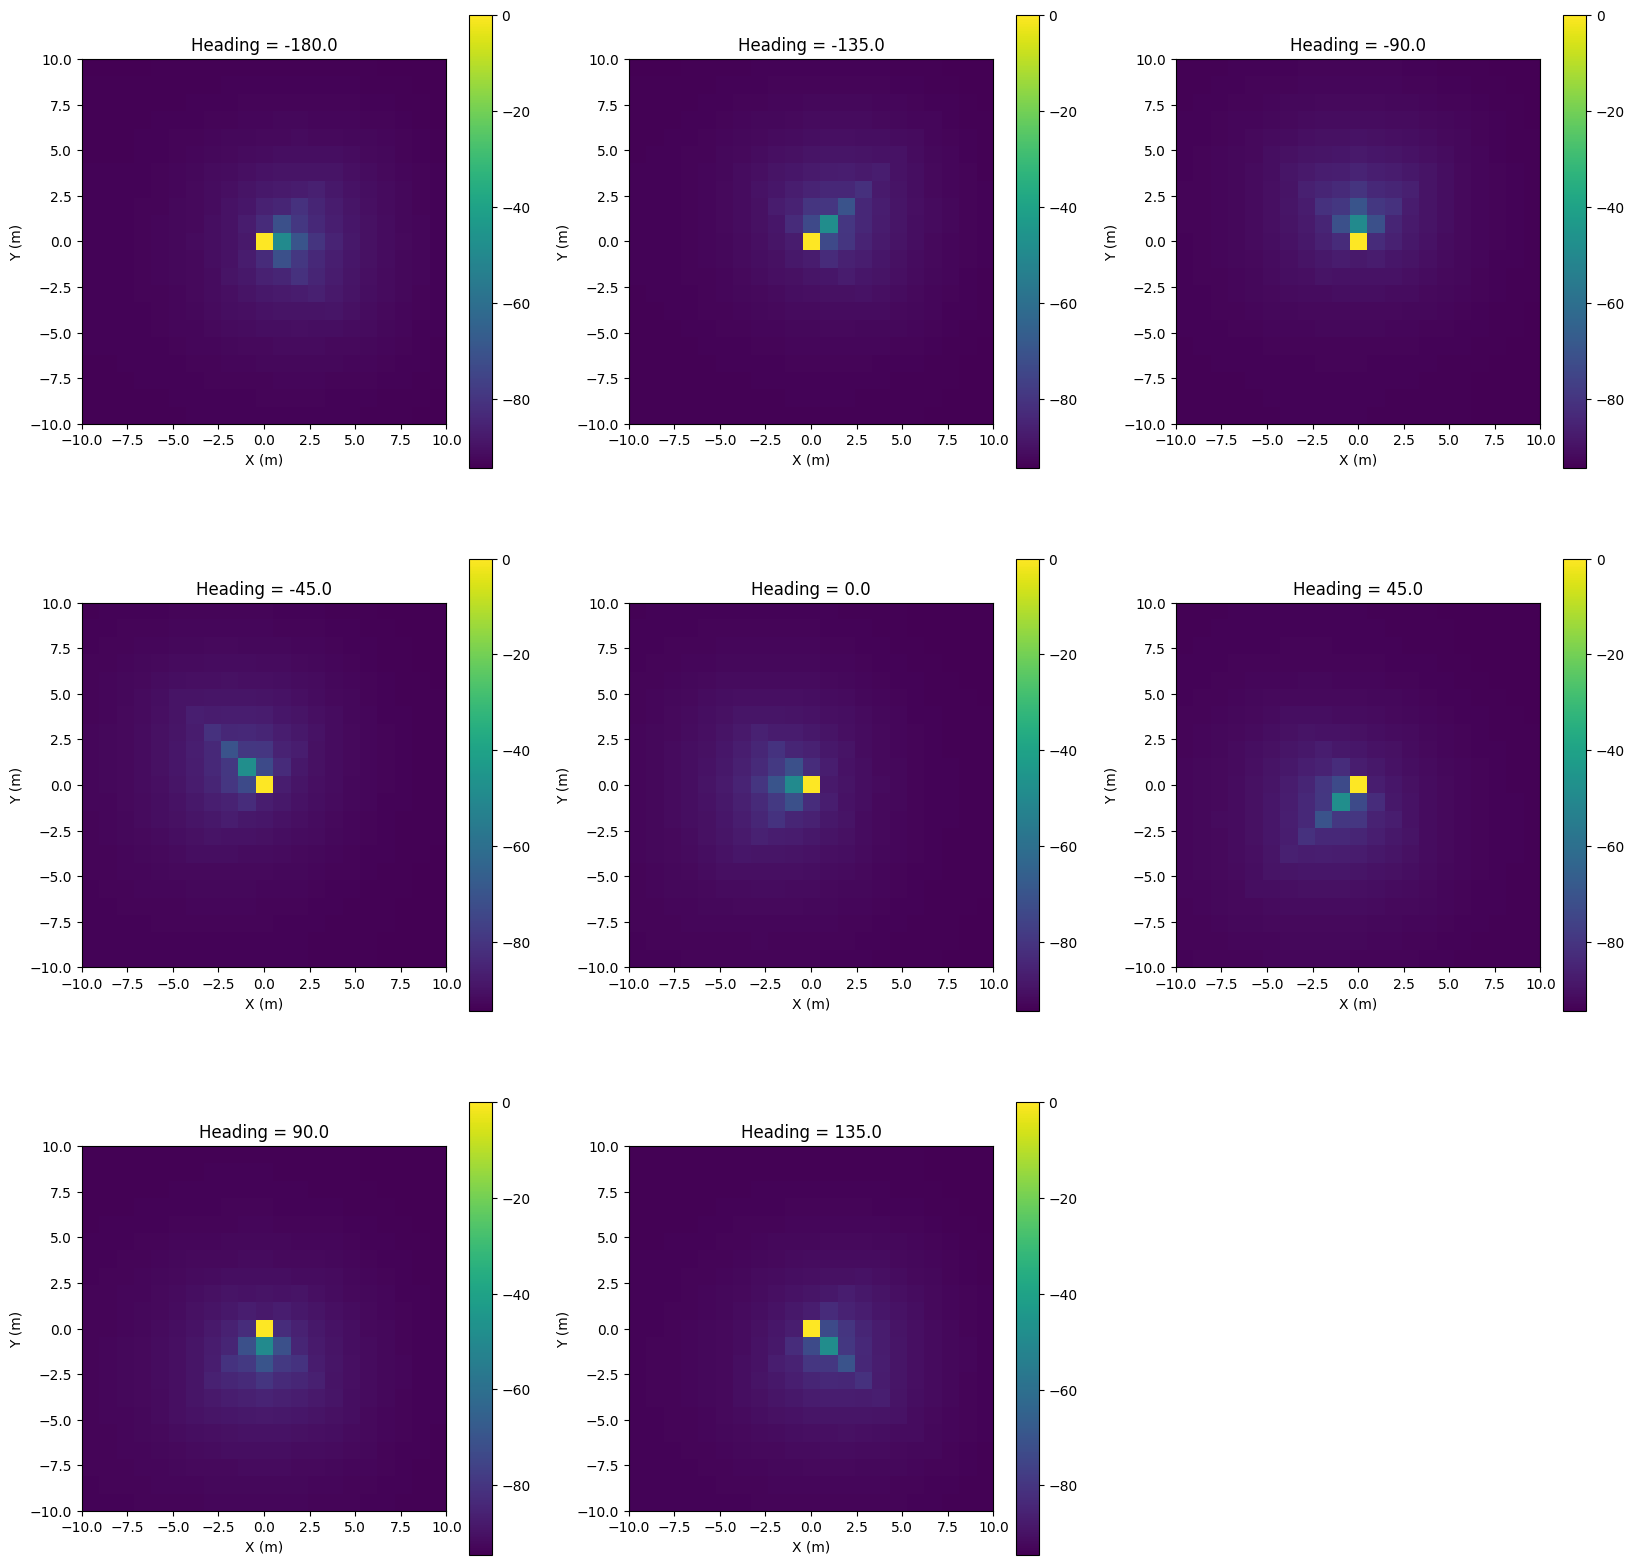

In [ ]:
plt.figure(figsize=(20, 20))
for h in range(env1.heading_space.shape[0]):
    plt.subplot(3, round(env1.heading_space.shape[0]/3), h + 1)
    plt.imshow(value_array[:, :, h].T, cmap='viridis', origin='lower', extent=[-10, 10, -10, 10])

    plt.title(f"Heading = {env1.heading_space[h]}")
    plt.colorbar()
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")

plt.show()

In [ ]:
from typing import Callable
from abc import ABC
class MonteCarloSampling(ABC):

    def __init__(self, env:GridEnv, max_rollout_depth:int=100):

        """self.value_array = np.zeros(env.state_space.shape[0])
        self.prev_value_array = self.value_array.copy()"""

        self.reset_value()
        self.gamma = 0.99
        self.env = env

        self.max_rollout_depth = max_rollout_depth

        self.transition_maxtrix = self.create_transition_matrix()
        self.value_delta = []


        self.value_array_ground_truth = valiter.value_array.copy()

        self.alpha = 0.2


    def reset_value(self):
        self.value_array = np.zeros(env.state_space.shape[0])
        self.prev_value_array = self.value_array.copy()

        self.returns_G = [[] for _ in range(self.value_array.shape[0])]

        return

    def run(self, num_rollout:int=30, first_visit:bool=True, incremental_update:bool=False, sweep_strategy:str="exhaustive", num_episodes:int=1000, value_array_file_name:str="value_array", save_frequency:int=5000):

        """
            This run the MC sampling method by looping through all states until convergence. Stop when convergence is achieved. Specifically, this allows to choose the state sampling strategy. Exhaustive sweep, random sweep, bandit-like sweep, etc

            input:
                - num_rollout: number of times to perform the rollout
                - first_visit: if true, implement the first visit MC, otherwise every-visit MC
        """

        delta_v = 1
        epsilon = 1e-2

        self.value_delta = []
        if sweep_strategy=="exhaustive":
            num_episodes = self.env.state_space.shape[0]

        iterator = tqdm(iterable=range(num_episodes), desc="episode: ", total=num_episodes)

        if incremental_update:
            mc_simulate = self.mc_prediction_incr
        else:
            mc_simulate = self.mc_prediction

        for iter in iterator:
            if sweep_strategy=="exhaustive":
                state = self.env.state_space[iter]
            elif sweep_strategy=="random":
                state = random.choice(self.env.state_space)
            else:
                raise f"Unknown sweep startegy: {sweep_strategy}, only have (exhaustive, random) yet"


            mc_simulate(state=state, num_rollout=num_rollout, first_visit=first_visit, policy=self.rollout_policy_rand)

            delta_v = np.linalg.norm(self.value_array-self.value_array_ground_truth)
            self.value_delta.append(delta_v)
            self.prev_value_array = self.value_array.copy()

            if iter % save_frequency == 0:
                self.save(self.value_array, file_name=value_array_file_name)

            print(f"=============================================")
            print(f"[ITERATION N°{iter}] delta_v: {delta_v}")


            if delta_v<epsilon:
                break
        self.save(self.value_array, file_name=value_array_file_name)
        return


    def mc_prediction(self, state, policy:Callable, num_rollout:int=30, first_visit=True, plot=False):
        """
            This is like mc_rollout but performs a certain number of rollouts and update return of each visited state. Basically computes the value of a state using the MC sampling technique

            input:
             - state: starting state of the rollout
             - num_rollout: number of times to perfom the rollout
             - first_visit: if true, implement the first visit MC, otherwise every-visit MC

        """

        iterator = range(num_rollout) #tqdm(iterable=range(num_rollout), desc="rollout: ", total=num_rollout)

        for _ in iterator:
            rewards, trajectory = self.mc_rollout(state, plot=plot, policy=policy) # Added policy=self.rollout_policy here
            G_t = 0
            # Loop backward to update the return of each state
            for t in range(1, len(rewards)+1):

                G_t = self.gamma*G_t + rewards[-t] # G_t = R_{t+1} + gamma*G_{t+1}
                state_idx = trajectory[-t]
                #state_idx = self.env.state_to_idx(state)

                if self.env.is_terminal_state(self.env.state_space[state_idx]):
                    continue
                # Check whether this state appeared earlier in the trajectory or not. If not, then, this is its first visit
                if first_visit:

                    if state_idx not in trajectory[:-t]:
                        self.returns_G[state_idx].append(G_t)
                        self.value_array[state_idx] = np.array(self.returns_G[state_idx]).mean()

                else:
                    self.returns_G[state_idx].append(G_t)
                    self.value_array[state_idx] = np.array(self.returns_G[state_idx]).mean()

        return


    def mc_prediction_incr(self, state, policy:Callable, num_rollout:int=30, first_visit=True, plot=False):

        """
            This is like the mc_prediction but compute the value of a state using incremental update instead of storing all the returns. This allows more flexible update by choosing a learning rate different than 1/N, useful in non-stationary tasks

            input:
             - state: starting state of the rollout
             - num_rollout: number of times to perfom the rollout
             - first_visit: if true, implement the first visit MC, otherwise every-visit MC

        """

        iterator = range(num_rollout) #tqdm(iterable=range(num_rollout), desc="rollout: ", total=num_rollout)

        for _ in iterator:
            rewards, trajectory = self.mc_rollout(state, plot=plot, policy=policy)
            G_t = 0
            # Loop backward to update the return of each state
            for t in range(1, len(rewards)+1):

                G_t = self.gamma*G_t + rewards[-t] # G_t = R_{t+1} + gamma*G_{t+1}
                state_idx = trajectory[-t]
                #state_idx = self.env.state_to_idx(state)

                if self.env.is_terminal_state(self.env.state_space[state_idx]):
                    continue

                # Check whether this state appeared earlier in the trajectory or not. If not, then, this is its first visit
                if first_visit:

                    if state_idx not in trajectory[:-t]:

                        self.value_array[state_idx] = self.value_array[state_idx] + self.alpha*(G_t - self.value_array[state_idx]) # V(s) = V(s) + \alpha * (G_t - V(s))

                else:
                    self.value_array[state_idx] = self.value_array[state_idx] + self.alpha*(G_t - self.value_array[state_idx]) # V(s) = V(s) + \alpha * (G_t - V(s))

        return


    def mc_rollout(self, state:np.ndarray, action=None, plot=False, fig=None, policy:Callable=None, *args, **kwargs):
        """
            This performs a single trial/rollout/simulation starting from a given state until a terminal state and collect the rewards obtained all the way along

            input:
                - state:starting state of the rollout
                - policy: policy used to do rollout
            return:
                - trajectory (list[np.ndarray]) : sequence of states visited
                - rewards (list[float]): reward obtained at each time step
        """

        trajectory = []
        rewards = []

        done = False
        current_state = state.copy()

        # Check if we must add actions to the trajectory (Action-Value / Control context)
        add_actions = (action is not None) or (policy == self.mc_control)
        exploring_start = action is not None

        for i in range(self.max_rollout_depth):
            # 1. Determine action if not exploring start
            if not exploring_start:
                if policy is None:
                    action = self.rollout_policy_rand(current_state)
                else:
                    action = policy(current_state, *args, **kwargs)

            # 2. Record S_t (and A_t) BEFORE transition occurs
            s_idx = self.env.state_to_idx(current_state)
            if add_actions:
                a_idx = self.env.action_space.index(action)
                trajectory.append((s_idx, a_idx))
            else:
                trajectory.append(s_idx)

            # 3. Step transition in environment
            next_state, reward, done = self.transition_maxtrix[self.state_to_str(current_state)][action]

            # 4. Record reward R_{t+1}
            rewards.append(reward)

            # 5. Move to next state
            current_state = next_state.copy()
            exploring_start = False

            if done:
                break

            if done:
                break


        if plot:

            if add_actions:
                trajectory.append((self.env.state_to_idx(current_state.copy()), self.env.action_space.index(action)))
                real_trajectory = [self.env.state_space[state_idx[0]] for state_idx in trajectory]
            else:
                trajectory.append(self.env.state_to_idx(current_state.copy()))
                real_trajectory = [self.env.state_space[state_idx] for state_idx in trajectory]

            xs, ys, thetas = zip(*real_trajectory)
            self.plot_traj(xs, ys, thetas, state, fig=fig)

        return rewards, trajectory

    def rollout_policy_rand(self, state):

        """ This is the policy used to do a MC simulation
            Here we use a uniform random policy
        """

        return random.choice(self.env.action_space)

    def mc_control(self, state, *args, **kwargs):
        pass

    def save(self, value_array:np.ndarray, save_dir:str="/content/drive/MyDrive/rl_checkpoints/", file_name:str="value_array"):
        """ Save the value array on google drive """
        os.makedirs(save_dir, exist_ok=True)

        path = os.path.join(save_dir, file_name+".npy")
        # Save the action-value array
        np.save(path, value_array)

        print(f"Arrays successfully saved to Google Drive!: {path}")

    def load(self, value_array:np.ndarray, save_dir:str="/content/drive/MyDrive/rl_checkpoints/", file_name:str="value_array"):

        path = os.path.join(save_dir, file_name+".npy")
        if os.path.exists(path):
            value_array[:] = np.load(path, allow_pickle=True)
            print("Action-value array successfully loaded!")
        else:
            print("Checkpoint file not found.")

    # =========== Helper Functions for MC Sampling implementation ============ #

    def create_transition_matrix(self):
        """
        This is the dynamic funtion of the discrete environment. Instead of calling env.step every step, we simply look-up the next state given current action. However, this is not necessary in MC sampling
        """

        transition = {} # {state: {action1: next_state_1, action2: next_state2, ...}, ...}
        for state in self.env.state_space:
            transition[self.state_to_str(state)] = {}
            for action in self.env.action_space:
                self.env.rb.reset(state)
                next_state, reward, done = self.env.step(action)
                reward = self.env.reward_model(state, action, next_state)
                transition[self.state_to_str(state)][action] = (next_state, reward, done)

        return transition


    def state_to_str(self, state):

        return f"({state[0]}, {state[1]}, {state[2]})"

    def plot_traj(self, xs, ys, thetas, state, fig=None):

        if fig is None:
            # --- Plot the trajectory ---
            plt.figure(figsize=(8,8))
            plt.xlim(-15, 15)
            plt.ylim(-15, 15)
            plt.grid(True, linestyle='--', alpha=0.4)

        # Plot path
        plt.plot(xs, ys, '-o', markersize=3, label='Robot path')

        # Plot goal
        plt.scatter(self.env.goal_position[0], self.env.goal_position[1], color='red', s=80, label=f'Goal ({self.env.goal_position[0]}, {self.env.goal_position[1]})')
        plt.scatter(state[0], state[1], color='green', s=80, label=f'start ({state[0]},{state[1]})')

        # Plot orientation arrows
        for x, y, th in zip(xs, ys, thetas):  # every 3 steps for clarity
            plt.arrow(x, y, 0.4*np.cos(th), 0.4*np.sin(th),
                    head_width=0.2, head_length=0.2, fc='blue', ec='blue')

        plt.title("Robot trajectory under rollout policy (random)")
        plt.legend()


In [30]:
angle_step = 45 # degree
rb = Robot(1.1, angle_step)
env = GridEnv([-10.0, 10.0], [-10.0, 10.0], 1., angle_step, rb, np.array([0.0, 0.0]))
mcs = MonteCarloSampling(env, max_rollout_depth=10000)
test_state = np.array([-1., -1., 45.0])
test_state_idx = mcs.env.state_to_idx(test_state)
mcs.transition_maxtrix[mcs.state_to_str(test_state)]

{'stop': (array([-1., -1., 45.]), -1.0, False),
 'move': (array([ 0.,  0., 45.]), -0.0, True),
 'turn left': (array([-1., -1.,  0.]), -1.0, False),
 'turn right': (array([-1., -1., 90.]), -1.0, False)}

### Monte Carlo Prediction with Multiple Seeds

To get a more robust comparison between 'first visit' and 'every visit' Monte Carlo prediction, we will run the simulation multiple times with different random seeds. This allows us to observe the average behavior and the variability (standard deviation) of the value estimates over time.

We will perform `num_seeds` simulations, and for each simulation, we will run `num_episodes_per_seed` episodes from the `test_state` for both first-visit and every-visit approaches. The `mcs` object's internal value array will be reset for each new seed to ensure independence.

In [32]:
num_seeds = 20 # Number of different random seeds to use
num_episodes_per_seed = 500 # Number of episodes for each seed

all_value_list_first = []
all_value_list_every = []

print(f"Running {num_seeds} simulations with {num_episodes_per_seed} episodes each...")

for seed in tqdm(range(num_seeds), desc="Simulations"): # Using tqdm for progress bar
    # Set seed for reproducibility
    random.seed(seed)
    np.random.seed(seed)

    # --- First Visit MC ---
    mcs.reset_value() # Reset mcs for a fresh start for this seed
    current_seed_value_list_first = []
    for _ in range(num_episodes_per_seed):
        mcs.mc_prediction(test_state, mcs.rollout_policy_rand, num_rollout=1, first_visit=True, plot=False)
        current_seed_value_list_first.append(mcs.value_array[test_state_idx])
    all_value_list_first.append(current_seed_value_list_first)

    # --- Every Visit MC ---
    mcs.reset_value() # Reset mcs again for every visit for this seed
    current_seed_value_list_every = []
    for _ in range(num_episodes_per_seed):
        mcs.mc_prediction(test_state, mcs.rollout_policy_rand, num_rollout=1, first_visit=False, plot=False)
        current_seed_value_list_every.append(mcs.value_array[test_state_idx])
    all_value_list_every.append(current_seed_value_list_every)

# Convert to numpy arrays for easier calculations
all_value_list_first = np.array(all_value_list_first)
all_value_list_every = np.array(all_value_list_every)

# Calculate mean and standard deviation across seeds for each episode
mean_value_first = np.mean(all_value_list_first, axis=0)
std_value_first = np.std(all_value_list_first, axis=0)

mean_value_every = np.mean(all_value_list_every, axis=0)
std_value_every = np.std(all_value_list_every, axis=0)

print("Simulation complete. Ready to plot.")

Running 20 simulations with 500 episodes each...


Simulations: 100%|██████████| 20/20 [20:05<00:00, 60.28s/it]

Simulation complete. Ready to plot.


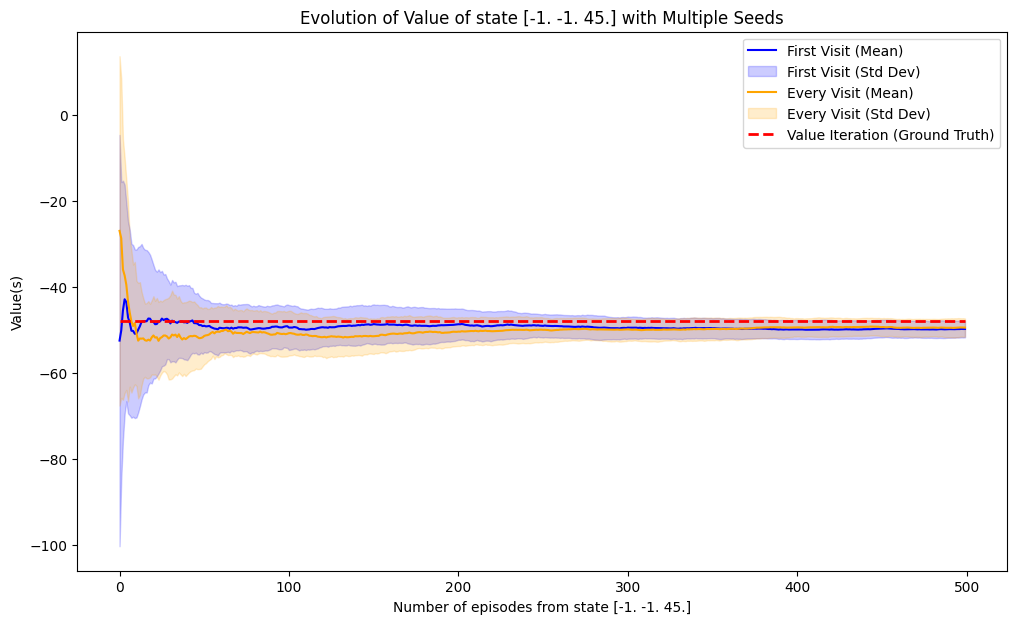

In [33]:
plt.figure(figsize=(12, 7))

episodes = np.arange(num_episodes_per_seed)

# Plot First Visit MC
plt.plot(episodes, mean_value_first, label=f"First Visit (Mean)", color='blue')
plt.fill_between(episodes, mean_value_first - std_value_first, mean_value_first + std_value_first, color='blue', alpha=0.2, label='First Visit (Std Dev)')

# Plot Every Visit MC
plt.plot(episodes, mean_value_every, label=f"Every Visit (Mean)", color='orange')
plt.fill_between(episodes, mean_value_every - std_value_every, mean_value_every + std_value_every, color='orange', alpha=0.2, label='Every Visit (Std Dev)')

# Plot Value Iteration Ground Truth
plt.hlines(valiter.value_array[test_state_idx], 0, num_episodes_per_seed - 1, label="Value Iteration (Ground Truth)", colors="red", linestyle='--', linewidth=2)

plt.title(f"Evolution of Value of state {test_state} with Multiple Seeds")
plt.ylabel("Value(s)")
plt.xlabel(f"Number of episodes from state {test_state}")
plt.legend()
plt.show()

-2735.0


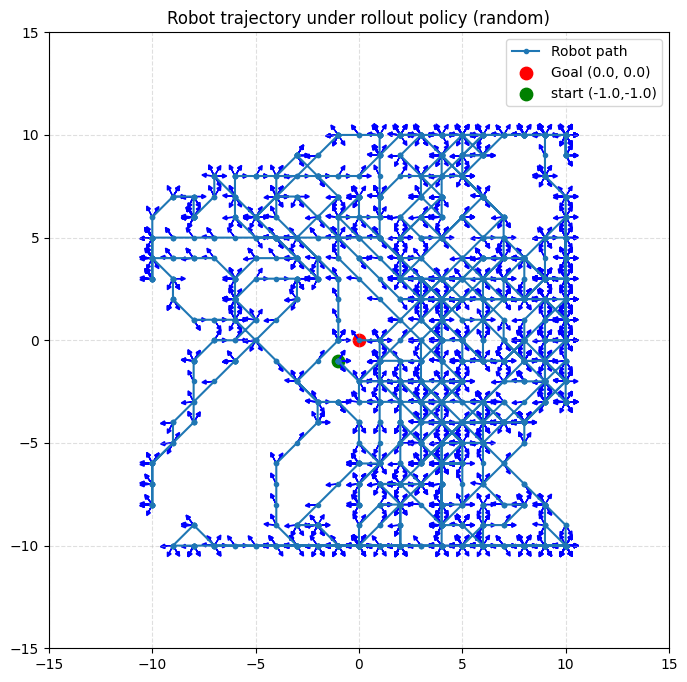

In [ ]:
rewards, trajectory = mcs.mc_rollout(test_state, policy=mcs.rollout_policy_rand, plot=True)
print(sum(rewards))

In [ ]:
# Correctly use timeit to measure the execution of valiter.run(200)
#execution_time = timeit(lambda: mcs.run(num_iter=1, num_rollout=100), number=1)
#execution_time = timeit(lambda: mcs.mc_first_visit(test_state, 1))
#print(f"Execution time for valiter.run(200): {execution_time:.4f} seconds")
mcs.run(num_rollout=1, first_visit=False, incremental_update=False, save_frequency=1500, sweep_strategy="exhaustive")
print(f"Percentage of updated states: {(np.count_nonzero(mcs.value_array))/(mcs.value_array.shape[0]-1)}")
value_delta_normal = mcs.value_delta.copy()

In [ ]:
mcs.save(mcs.value_array)


Arrays successfully saved to Google Drive!: /content/drive/MyDrive/rl_checkpoints/value_array.npy
Action-value array successfully loaded!


In [31]:
mcs.load(mcs.value_array)

Action-value array successfully loaded!


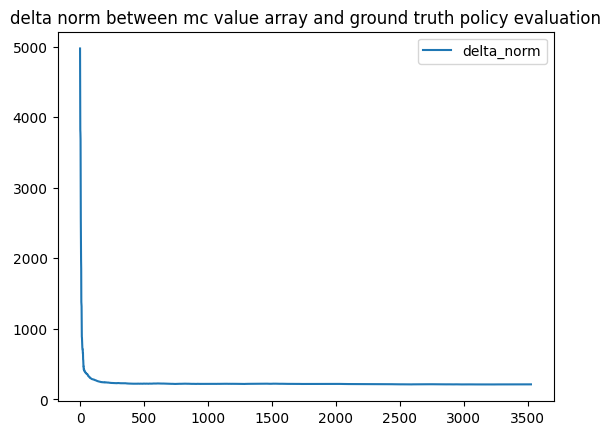

In [ ]:
plt.plot(mcs.value_delta, label="delta_norm")
plt.title("delta norm between mc value array and ground truth policy evaluation")
plt.legend()

In [ ]:
value_array = mcs.value_array.copy()

In [ ]:
#plt.plot(value_delta_normal)
value_array = value_array.reshape(env.x_space.shape[0], env.y_space.shape[0], env.heading_space.shape[0])
#value_array[:10]

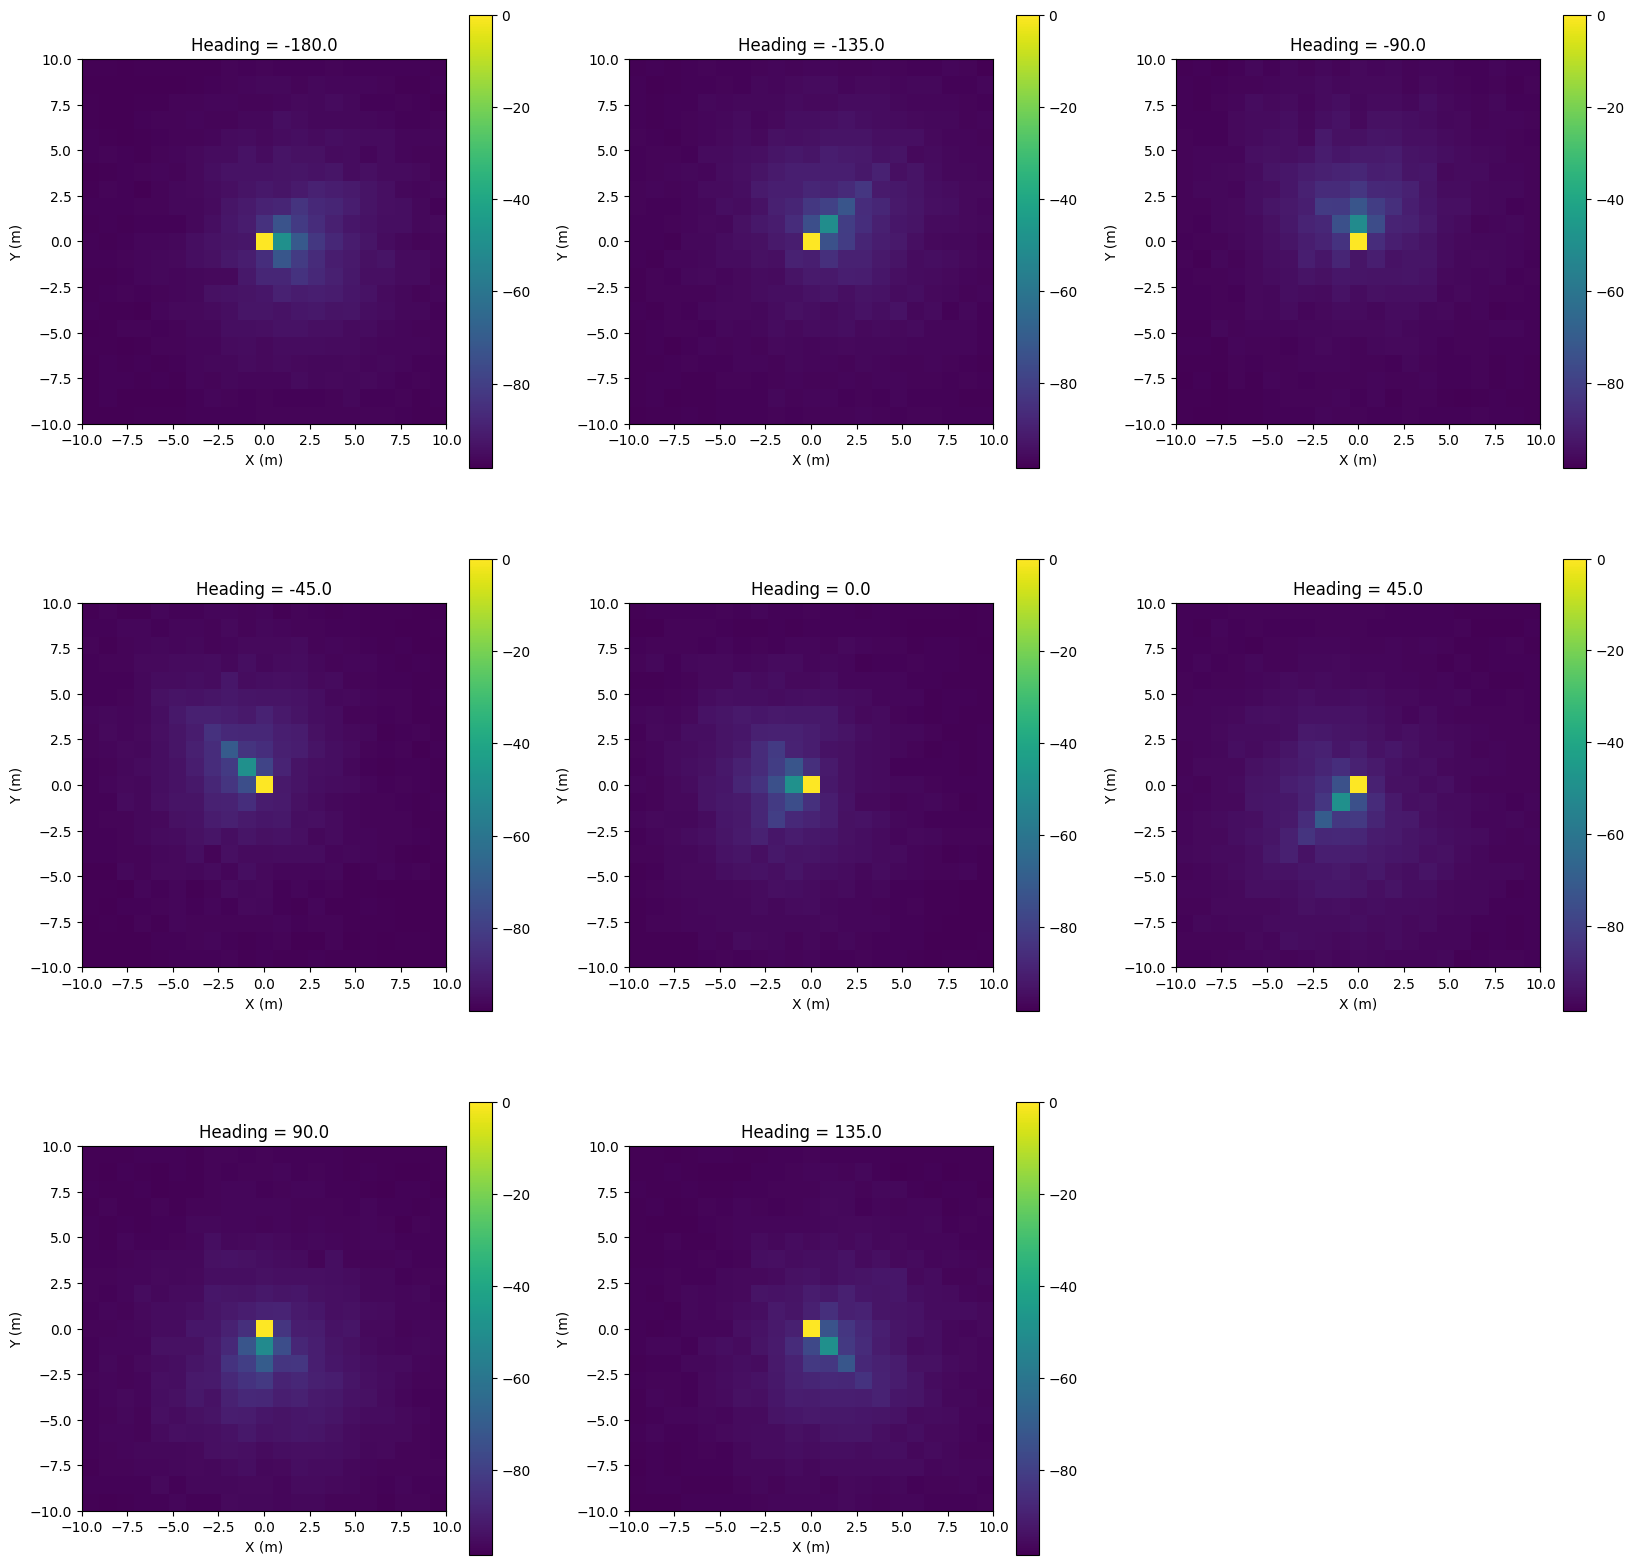

In [ ]:
plt.figure(figsize=(20, 20))
for h in range(env.heading_space.shape[0]):
    plt.subplot(3, round(env.heading_space.shape[0]/3), h + 1)
    plt.imshow(value_array[:, :, h].T, cmap='viridis', origin='lower', extent=[-10, 10, -10, 10])

    plt.title(f"Heading = {env.heading_space[h]}")
    plt.colorbar()
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")

plt.show()

In [34]:
class MonteCarloSamplingActionValue(MonteCarloSampling):

    def __init__(self, env:GridEnv, max_rollout_depth:int=100):

        super().__init__(env, max_rollout_depth)

        self.action_value_array = -100 + np.zeros((env.state_space.shape[0], len(env.action_space)))

        # Zero out terminal states
        for idx, st in enumerate(env.state_space):
            if env.is_terminal_state(st):
                self.action_value_array[idx, :] = 0.0

        self.prev_value_array = self.action_value_array.copy()

        self.alpha = 0.1


    def run(self, num_rollout:int=30, first_visit:bool=True, incremental_update:bool=False, sweep_strategy:str="exhaustive", num_episodes:int=1000, is_deterministic=True, action_value_file_name:str="action_value_array", save_frequency:int=5000, eval_frequency:int=400, alpha:float=0.1, beta_start:float=0.0, beta_end:float=0.2, end_time=1):

        """
            This run the MC sampling method by looping through all states until convergence. Stop when convergence is achieved. Specifically, this allows to choose the state sampling strategy. Exhaustive sweep, random sweep, bandit-like sweep, etc

            input:
                - num_rollout: number of times to perform the rollout
                - first_visit: if true, implement the first visit MC, otherwise every-visit MC
                - beta_start: starting beta
                - beta_end: end beta, reached at the end in the last episode
                - end_time: if 1. beta_end is reached at 100% of num_episode i.e. the last episode; if 0.7 beta_end is reached at episode number = int(0.7*num_episode)
        """

        delta_v = 1
        epsilon = 1e-3
        self.alpha = alpha
        self.value_delta = []

        rewards_evolution = []

        n = self.action_value_array.shape[0]
        final_schedule_time = int(end_time*num_episodes)

        if sweep_strategy=="exhaustive":

            num_episodes = n if n > num_episodes else num_episodes #np.prod(self.action_value_array.shape)

        #iterator = tqdm(iterable=range(num_episodes), desc="episode: ", total=num_episodes)

        iterator = range(num_episodes)
        mc_simulate = self.mc_prediction_incr

        for iter in iterator:

            beta = beta_start + (beta_end - beta_start) * (iter / final_schedule_time)

            if sweep_strategy=="exhaustive":
                state = self.env.state_space[iter % n]

            elif sweep_strategy=="random":
                state = random.choice(self.env.state_space)

            else:
                raise f"Unknown sweep startegy: {sweep_strategy}, only have (exhaustive, random) yet"

            for action in self.env.action_space:
                #action = random.choice(self.env.action_space) # action always chosen randomly
                mc_simulate(state=state, num_rollout=num_rollout, first_visit=first_visit, action=action, policy=self.mc_control, is_deterministic=is_deterministic, beta=beta)

            delta_v = np.abs(np.linalg.norm(self.action_value_array) - np.linalg.norm(self.prev_value_array))
            self.value_delta.append(delta_v)
            self.prev_value_array = self.action_value_array.copy()

            if iter % save_frequency == 0:
                self.save(self.action_value_array, file_name=action_value_file_name)

            if iter % eval_frequency == 0:
                rew = self.evaluate_policy(test_state=np.array([-10.0, 10.0, 135.0]))

                rewards_evolution.append(rew)

                print(f"=============================================")
                print(f"[ITERATION N°{iter}] reward: {rew}")



            """if delta_v<epsilon:
                break"""

        self.save(self.action_value_array, file_name=action_value_file_name)
        return rewards_evolution


    def mc_prediction_incr(self, state, policy:Callable, num_rollout:int=30, first_visit=True, action=None, *args, **kwargs):

        """
            This is like the mc_prediction but compute the value of a state using incremental update instead of storing all the returns. This allows more flexible update by choosing a learning rate different than 1/N, useful in non-stationary tasks

            input:
             - state: starting state of the rollout
             - num_rollout: number of times to perfom the rollout
             - first_visit: if true, implement the first visit MC, otherwise every-visit MC

        """

        iterator = range(num_rollout) #tqdm(iterable=range(num_rollout), desc="rollout: ", total=num_rollout)

        for _ in iterator:
            rewards, trajectory = self.mc_rollout(state, action=action, policy=self.mc_control, *args, **kwargs)
            G_t = 0 # this is G_T final and it's zero only when final state is reached otherwise can be boostrapped by setting G_T = v(s')

            # Loop backward to update the return of each state
            for t in range(1, len(rewards)+1):

                G_t = self.gamma*G_t + rewards[-t] # G_t = R_{t+1} + gamma*G_{t+1}
                state_action_idx = trajectory[-t] # Fixed: changed -t-1 to -t
                state_idx, action_idx = state_action_idx
                #state_idx = self.env.state_to_idx(state)

                if self.env.is_terminal_state(self.env.state_space[state_idx]):
                    continue

                # Check whether this state appeared earlier in the trajectory or not. If not, then, this is its first visit
                if first_visit:

                    if state_action_idx not in trajectory[:-t]: # Fixed: changed -t-1 to -t

                        self.action_value_array[state_idx, action_idx] = self.action_value_array[state_idx, action_idx] + self.alpha*(G_t - self.action_value_array[state_idx, action_idx]) # V(s) = V(s) + \alpha * (G_t - V(s))

                else:
                    self.action_value_array[state_idx, action_idx] = self.action_value_array[state_idx, action_idx] + self.alpha*(G_t - self.action_value_array[state_idx, action_idx]) # V(s) = V(s) + \alpha * (G_t - V(s))

        return


    def mc_control(self, state, is_deterministic:bool=True, beta:float=1.0):

        """ This function computes the policy from the current value function. We compute the policy as a softmax over the action values of the current state. action with high action-value will have higher probability

        input:
            - state: current state
            - is_deterministic: if True, then action is the argmax_a Q(s, a); else samples from the distribution of actions
            - beta: softmax temperature
        output:
            - action distribution at the current state

        """

        state_idx = self.env.state_to_idx(state)
        if is_deterministic:
            action_idx = np.argmax(self.action_value_array[state_idx])
            #print(f"hey, is_deterministic: {is_deterministic}")
            return self.env.action_space[action_idx]

        else:
            action_dist = np.exp(beta*self.action_value_array[state_idx])/(np.exp(beta*self.action_value_array[state_idx]).sum())
            action = random.choices(self.env.action_space, weights=action_dist, k=1)[0]
            #print(f"state: {state} , action_dist: {action_dist} action: {action}")
            #print(f"hey hey, is_deterministic: {is_deterministic}")
            return action

    def evaluate_policy(self, test_state:np.ndarray):
        """
            This function will be used to evaluate the policy during training and observe the progression of the policy performance
        """

        rewards, trajectory = self.mc_rollout(test_state, policy=self.mc_control, is_deterministic=True)

        sum_rewards = np.sum(rewards)

        return sum_rewards




In [35]:
angle_step = 45 # degree
rb = Robot(2.1, angle_step)
env = GridEnv([-10.0, 10.0], [-10.0, 10.0], 1., angle_step, rb, np.array([0., 0.]))
mcs_av = MonteCarloSamplingActionValue(env, max_rollout_depth=10000)

In [ ]:
env.x_space

array([-10.,  -9.,  -8.,  -7.,  -6.,  -5.,  -4.,  -3.,  -2.,  -1.,   0.,
         1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.])

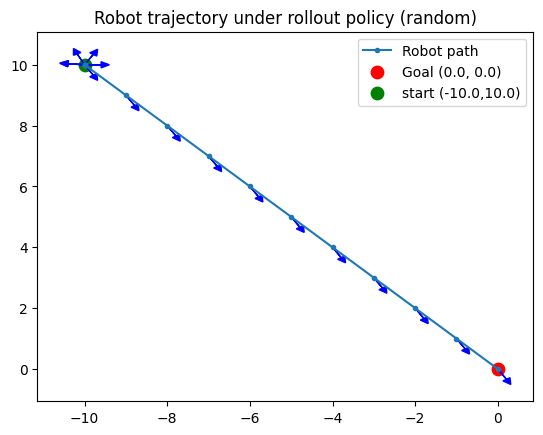

In [44]:
test_state = np.array([-10.0, 10.0, 135.0])
# --- Plot the trajectory ---
for _ in range(1):
    return_G, traj = mcs_av.mc_rollout(test_state, "stop", plot=True, fig=True, policy=mcs_av.mc_control, is_deterministic=True, beta=1.0)


In [36]:
mcs_av.load(mcs_av.action_value_array, file_name="action_value_array")

Action-value array successfully loaded!


In [ ]:
rewards_evolution = mcs_av.run(num_rollout=1, first_visit=False, incremental_update=False, sweep_strategy="exhaustive", num_episodes=50000, is_deterministic=False, save_frequency=500, eval_frequency=500, beta_start=0.0, beta_end=1., end_time=.9)

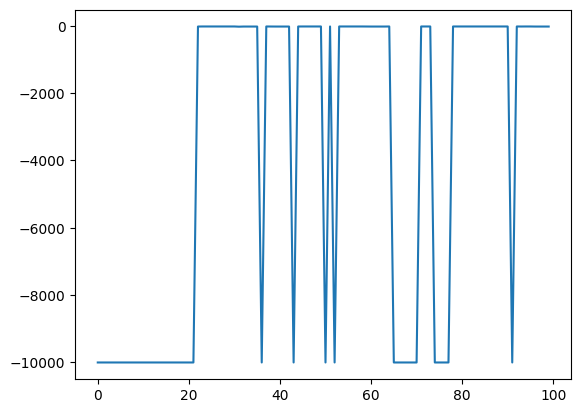

In [ ]:
plt.plot(rewards_evolution, label="reward evolution")

In [ ]:
mcs_av.load(mcs_av.action_value_array, file_name="action_value_array")


Action-value array successfully loaded!


In [ ]:
value_array = mcs_av.action_value_array.max(axis=1)

In [ ]:
value_array = value_array.reshape(env.x_space.shape[0], env.y_space.shape[0], env.heading_space.shape[0])
value_array

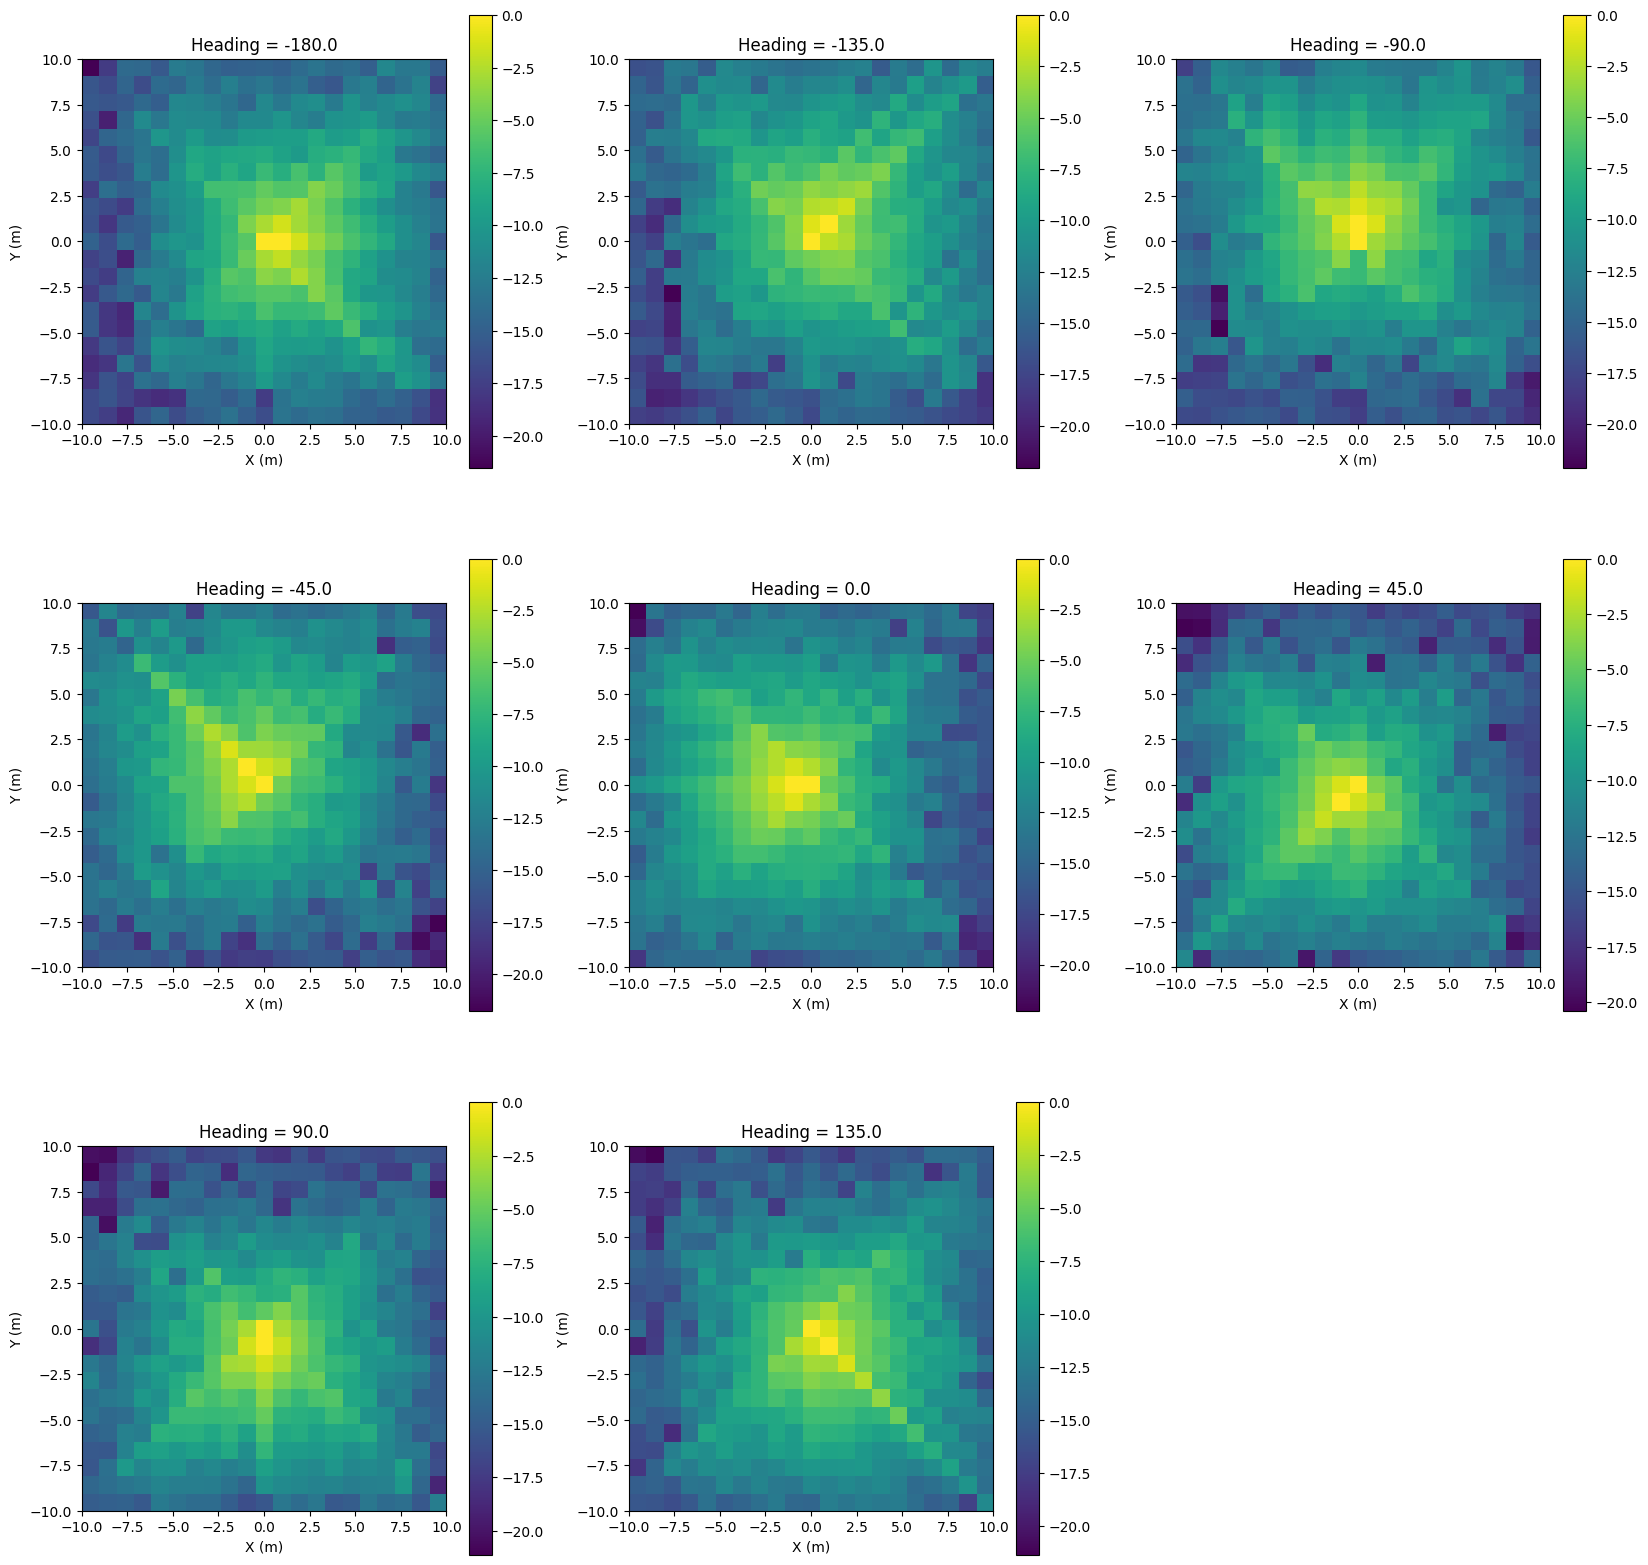

In [ ]:
plt.figure(figsize=(20, 20))
for h in range(env.heading_space.shape[0]):
    plt.subplot(3, round(env.heading_space.shape[0]/3), h + 1)
    plt.imshow(value_array[:, :, h].T, cmap='viridis', origin='lower', extent=[-10, 10, -10, 10])

    plt.title(f"Heading = {env.heading_space[h]}")
    plt.colorbar()
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")

plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Run the policy rollout and store the path ---

state = np.array([-10.0, 10.0, -45.0])
xs, ys, thetas = [], [], []
num_iter = 70
done = False
for i in range(num_iter):
    xs.append(state[0])
    ys.append(state[1])
    thetas.append(np.deg2rad(state[2]))

    action = mcs_av.mc_control(state, is_deterministic=False, beta=0.15)
    next_state, reward, done = mcs_av.transition_maxtrix[mcs_av.state_to_str(state)][action]
    print(f"=============================={i}====================================")
    print(f"state: {state}, action: {action}, next_state: {next_state}, done: {done}")
    print(f"qvalues: {mcs_av.action_value_array[mcs_av.env.state_to_idx(state)]}")

    state = next_state.copy()

    if done:
        xs.append(state[0])
        ys.append(state[1])
        thetas.append(np.deg2rad(state[2]))
        break

# --- Plot the trajectory ---
plt.figure(figsize=(8,8))
plt.xlim(-15, 15)
plt.ylim(-15, 15)
plt.grid(True, linestyle='--', alpha=0.4)

# Plot path
plt.plot(xs, ys, '-o', markersize=3, label='Robot path')

# Plot goal
plt.scatter(mcs_av.env.goal_position[0], mcs_av.env.goal_position[1], color='red', s=80, label=f'Goal ({mcs_av.env.goal_position[0]},{mcs_av.env.goal_position[1]})')

# Plot orientation arrows
for x, y, th in zip(xs, ys, thetas):  # every 3 steps for clarity
    plt.arrow(x, y, 0.4*np.cos(th), 0.4*np.sin(th),
              head_width=0.2, head_length=0.2, fc='blue', ec='blue')

plt.title("Robot trajectory under learned policy")
plt.legend()
plt.show()

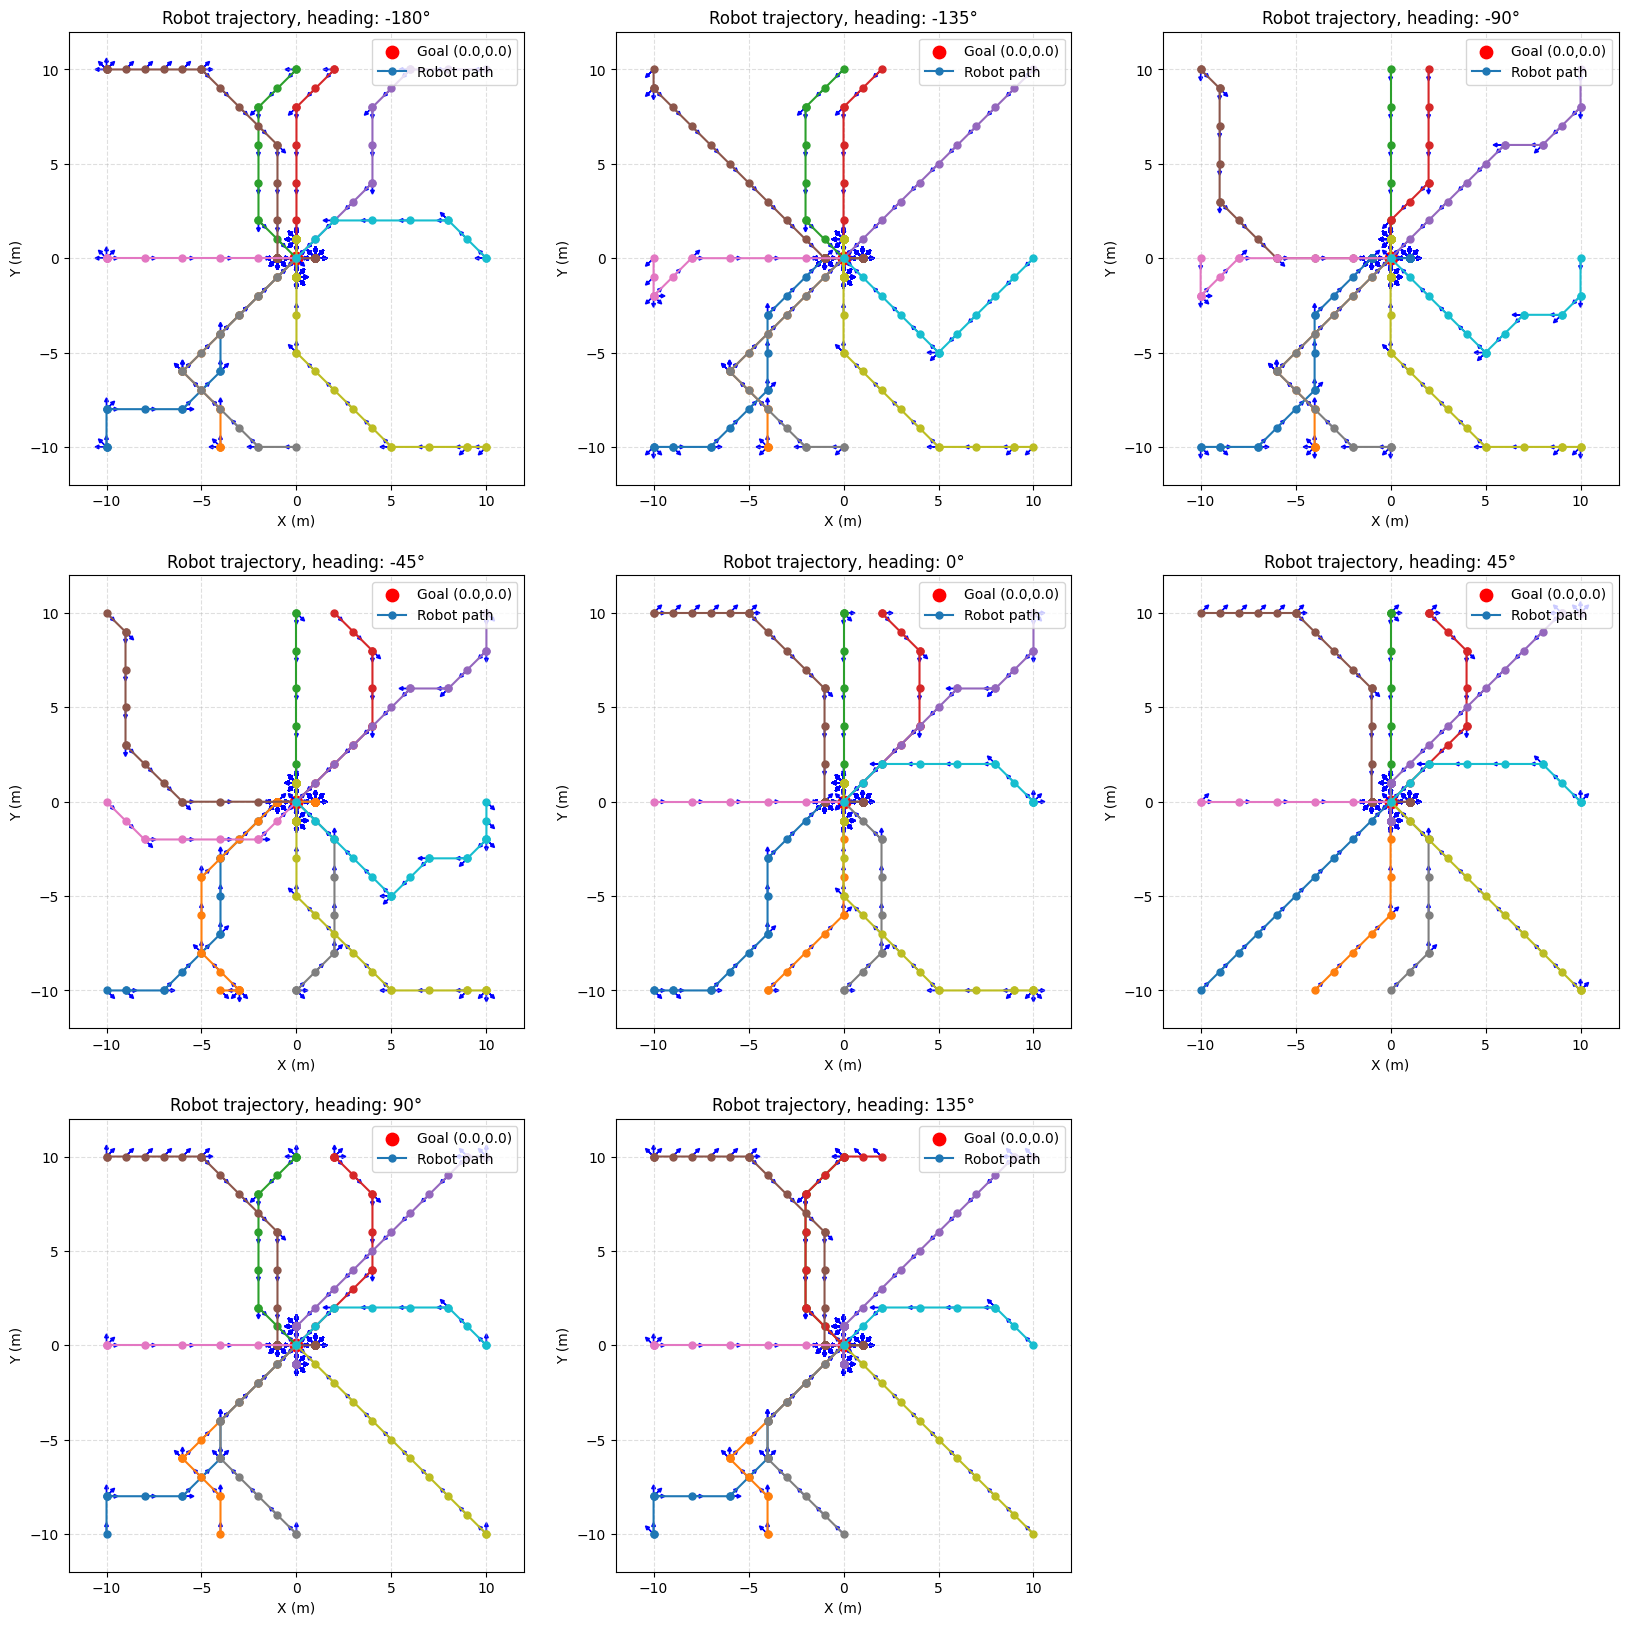

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# --- Run the policy rollout and store the path ---


# --- Plot the trajectory ---
plt.figure(figsize=(20,20))

num_iter = 300

heading_list = [-180, -135, -90, -45, 0, 45, 90, 135]
for j in range (len(heading_list)):

  heading = heading_list[j]
  state_list = [
      np.array([-10.0, -10.0, heading]), np.array([-4.0, -10.0, heading]), np.array([0.0, 10.0, heading]), np.array([2., 10.0, heading]), np.array([10.0, 10.0, heading]), np.array([-10.0, 10.0, heading]), np.array([-10.0, 0.0, heading]),
                np.array([0.0, -10.0, heading]), np.array([10.0, -10.0, heading]), np.array([10.0, 0.0, heading])
                ]
  plt.subplot(3, round(env.heading_space.shape[0]/3), j+1)
  plt.xlim(-12, 12)
  plt.ylim(-12, 12)
  plt.grid(True, linestyle='--', alpha=0.4)

  # Plot goal
  plt.scatter(mcs_av.env.goal_position[0], mcs_av.env.goal_position[1], color='red', s=80, label=f'Goal ({mcs_av.env.goal_position[0]},{mcs_av.env.goal_position[1]})')

  for i in range(len(state_list)):
    xs, ys, thetas = [], [], []

    # Fix for IndexError: ensure state is mapped to a valid discrete state
    initial_continuous_state = state_list[i]

    x_idx_raw = get_idx(initial_continuous_state[0], mcs_av.env.X_limit[0], mcs_av.env.position_step)
    y_idx_raw = get_idx(initial_continuous_state[1], mcs_av.env.Y_limit[0], mcs_av.env.position_step)
    heading_idx_raw = get_idx(initial_continuous_state[2], -180.0, mcs_av.env.heading_step)

    x_idx_clamped = max(0, min(x_idx_raw, len(mcs_av.env.x_space) - 1))
    y_idx_clamped = max(0, min(y_idx_raw, len(mcs_av.env.y_space) - 1))
    heading_idx_clamped = max(0, min(heading_idx_raw, len(mcs_av.env.heading_space) - 1))

    state_x = mcs_av.env.x_space[x_idx_clamped]
    state_y = mcs_av.env.y_space[y_idx_clamped]
    state_heading = mcs_av.env.heading_space[heading_idx_clamped]

    state = np.array([state_x, state_y, state_heading])

    done = False
    for k in range(num_iter): # Changed 'i' to 'k' to avoid shadowing outer loop variable
        xs.append(state[0])
        ys.append(state[1])
        thetas.append(np.deg2rad(state[2]))

        action = mcs_av.mc_control(state, is_deterministic=True)
        # Fix for AttributeError: Use mcs_av.mcs as the transition matrix
        next_state, reward, done = mcs_av.transition_maxtrix[mcs_av.state_to_str(state)][action]

        state = next_state.copy()

        if done:
            xs.append(state[0])
            ys.append(state[1])
            thetas.append(np.deg2rad(state[2]))
            break

    # Plot path
    if i==0:
        plt.plot(xs, ys, '-o', markersize=5, label='Robot path')
    else:
        plt.plot(xs, ys, '-o', markersize=5)
    plt.xlabel("X (m)")
    plt.ylabel("Y (m)")

    # Plot orientation arrows
    for x, y, th in zip(xs, ys, thetas):  # every 3 steps for clarity
        plt.arrow(x, y, 0.4*np.cos(th), 0.4*np.sin(th),
                  head_width=0.2, head_length=0.2, fc='blue', ec='blue')



  plt.title(f"Robot trajectory, heading: {heading}°")
  plt.legend(loc="upper right")

plt.show()